# Table of Contents

- [Before your start:](#before-your-start:)
  - [0.1 Read the README.md file](#before-your-start:)
  - [0.2 Introduction](#before-your-start:)
  - [0.3 Dataset](#dataset)
  - [0.4 Libraries](#libraries)

- [Challenge 1 - Exploratory Data Analysis (EDA)](#challenge-1---exploratory-data-analysis-(eda))
  - [1.1 Bivariate analysis](#explore-the-data-from-an-bird's-eye-view.)
  - [1.2 Evaluate correlations between columns](#evaluate-correlations-between-columns)
  - data selection
  - data cleaning
  - data preprocessing
  - imbalanced dataset

solo los titulos con hupervinculo. el resto sin.






- [Challenge 2 - Data Preprocessing](#challenge-2---remove-column-collinearity)

- [Challenge 3 - Handle Missing Values](#challenge-3---handle-missing-values)
  - [3.1 Handle missing values](#handle-missing-values)
  - [3.2 Examine the number of missing values in each column](#examine-the-number-of-missing-values-in-each-column)

- [Challenge 4 - Handle WHOIS Categorical Data](#challenge-4---handle-whois-categorical-data)
  - [4.1 Fix the country values](#fix-the-country-values)
  - [4.2 Consolidate low-frequency values](#consolidate-low-frequency-values)
  - [4.3 Keep the top 10 values and label the rest as OTHER](#keep-the-top-10-values-and-label-the-rest-as-other)
  - [4.4 Drop unnecessary columns](#drop-unnecessary-columns)

- [Challenge 5 - Handle Remaining Categorical Data & Convert to Ordinal](#challenge-5---handle-remaining-categorical-data--convert-to-ordinal)
  - [5.1 Handle URL](#handle-url)
  - [5.2 Examine unique values of CHARSET](#examine-unique-values-of-charset)
  - [5.3 Convert categorical variables to ordinal](#convert-categorical-variables-to-ordinal)

- [Challenge 6 - Modeling, Prediction, and Evaluation](#challenge-6---modeling-prediction-and-evaluation)
  - [6.1 Train and compare different models](#train-and-compare-different-models)
  - [6.2 Decision Tree Classifier](#decision-tree-classifier)
  - [6.3 Decision Tree Classifier with max_depth=5](#decision-tree-classifier-with-max_depth5)

- [Bonus Challenge - Feature Scaling](#bonus-challenge---feature-scaling)

# Before your start:
##### Read the README.md file
##### Introduction
In this notebook, we will explore a dataset that describes vehicle insurance claims with different features and labels them either fraudulent or non-fraudulent. We will use supervised learning algorithms to figure out what feature patterns fraudulent claims are likely to have and use our model to predict fraudulent claims. The purpose is to provide a detailed explanation of the process of building a classification model.

##### Dataset
*Source: [kaggle - vehicle-claim-fraud-detection](https://www.kaggle.com/datasets/shivamb/vehicle-claim-fraud-detection)*

Definition of Features

* **Month**: The month in which the insurance claim was made.
* **WeekOfMonth**: The week of the month in which the insurance claim was made.
* **DayOfWeek**: The day of the week on which the insurance claim was made. 
* **Make**: The manufacturer of the vehicle involved in the claim. 
* **AccidentArea**: The area where the accident occurred (e.g., urban, rural).
* **DayOfWeekClaimed**: The day of the week on which the insurance claim was processed. 
* **MonthClaimed**: The month in which the insurance claim was processed.
* **WeekOfMonthClaimed**: The week of the month in which the insurance claim was processed. 
* **Sex**: The gender of the policyholder.
* **MaritalStatus**: The material status of the policyholder. 
* **Age**: The age of the policyholder.
* **Fault**: Indicates whether the policyholder was at fault in the accident.
* **PolicyType**: The type of insurance policy (e.g., comprehensive, third-party).
* **VehicleCategory**: The category of the vehicle (e.g., sedan, SUV).
* **VehiclePrice**: The price of vehicle.
* **PolicyNumber**: The unique identifier for the insurance policy.
* **RepNumber**: The unique identifier for the insurance representative handling the claim. 
* **Deductible**: The amount that the policy holder must pay out of pocket before the insurance company pays the remaining costs.
* **DriverRating**: The rating of the driver, often based on driving history or other factors.
* **Days_Policy_Accident**: The number of days since the policy was issued until the accident occurred.
* **Days_Policy_Claim**: The number of days since the policy was issued until the claim was made.
* **PastNumberOfClaims**: The number of claims previously made by the policyholder.
* **AgeOfVehicle**: The age of the vehicle involved in the claim.
* **AgeOfPolicyHolder**: The age of the policyholder.
* **PoliceReportFiled**: Indicates whether a police report was filed for the accident.
* **WitnessPresent**: Indicates whether a witness was present at the scene of the accident.
* **AgentType**: The type of insurance agent handling the policy (e.g., internal, external) 
* **NumberOfSuppliments**: The number of supplementary documents or claims related to the main claim, categorized into ranges.
* **AddressChange_Claim**: Indicates whether the address of the policyholder was changed at the time of the claim, categorized into ranges.
* **NumberOfCars**: The number of cars insured under the policy, categorized into ranges.
* **Year**: The year in which the claim was made or processed. 
* **BasePolicy**: The base policy type (e.g., Liability, Collision, All Perils). 

Definition of Target

* **FraudFound_P**: Indicates whether fraud was detected in the insurance claim.

##### Libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



# Visualization - Plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Encoding
from sklearn.preprocessing import LabelEncoder

# Handling Outliers
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# SMOTE Oversampling
from imblearn.over_sampling import SMOTE

# VarianceThreshold
from sklearn.feature_selection import VarianceThreshold

# RFECV
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

# Machine Learning - Preparation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Machine Learning - Algorithm
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb

# Machine Learning - Optuna
#import optuna
#from optuna.samplers import TPESampler

# Machine Learning - Feature Importance
from sklearn.inspection import permutation_importance

# Challenge 1 - Exploratory Data Analysis (EDA)

In [299]:
raw_data = pd.read_csv('data/fraud_oracle.csv')
raw_data.shape

(15420, 33)

In [147]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15420 non-null

In [80]:
raw_data.isna().sum()

Month                   0
WeekOfMonth             0
DayOfWeek               0
Make                    0
AccidentArea            0
DayOfWeekClaimed        0
MonthClaimed            0
WeekOfMonthClaimed      0
Sex                     0
MaritalStatus           0
Age                     0
Fault                   0
PolicyType              0
VehicleCategory         0
VehiclePrice            0
FraudFound_P            0
PolicyNumber            0
RepNumber               0
Deductible              0
DriverRating            0
Days_Policy_Accident    0
Days_Policy_Claim       0
PastNumberOfClaims      0
AgeOfVehicle            0
AgeOfPolicyHolder       0
PoliceReportFiled       0
WitnessPresent          0
AgentType               0
NumberOfSuppliments     0
AddressChange_Claim     0
NumberOfCars            0
Year                    0
BasePolicy              0
dtype: int64

In [79]:
raw_data.duplicated().sum()

np.int64(0)

1. There are no missing or duplicate values

In [85]:
raw_data.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,21,Policy Holder,Sport - Liability,Sport,more than 69000,0,1,12,300,1,more than 30,more than 30,none,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,34,Policy Holder,Sport - Collision,Sport,more than 69000,0,2,15,400,4,more than 30,more than 30,none,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,47,Policy Holder,Sport - Collision,Sport,more than 69000,0,3,7,400,3,more than 30,more than 30,1,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,65,Third Party,Sedan - Liability,Sport,20000 to 29000,0,4,4,400,2,more than 30,more than 30,1,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,27,Third Party,Sport - Collision,Sport,more than 69000,0,5,3,400,1,more than 30,more than 30,none,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [106]:
def summarize(DataFrame):
    
    summary = pd.DataFrame()
    
    # Data Type
    summary['Data Type'] = DataFrame.dtypes
    # N Unique
    summary['N Unique'] = DataFrame.nunique()
    # Unique
    summary['Unique'] = DataFrame.apply(lambda x: x.unique().tolist())
    # Max
    summary['Max'] = DataFrame.apply(lambda x: x.max() if pd.api.types.is_numeric_dtype(x) else '-')
    # Min
    summary['Min'] = DataFrame.apply(lambda x: x.min() if pd.api.types.is_numeric_dtype(x) else '-')
    
    # Measures of Central Tendency: Mean, Median, Mode 
    summary['Mean'] = DataFrame.apply(lambda x: round(x.mean(), 2) if pd.api.types.is_numeric_dtype(x) else '-')
    summary['Median'] = DataFrame.apply(lambda x: x.median() if pd.api.types.is_numeric_dtype(x) else '-')
    summary['Mode'] = DataFrame.apply(lambda x: x.mode().iloc[0] if not x.mode().empty else '-')
    
    # Measures of Dispersion: Range, Variance, Standard Deviation
    summary['Range'] = DataFrame.apply(lambda x: x.max() - x.min() if pd.api.types.is_numeric_dtype(x) else '-')
    summary['Variance'] = DataFrame.apply(lambda x: x.var() if pd.api.types.is_numeric_dtype(x) else '-')
    summary['Standard Deviation'] = DataFrame.apply(lambda x: x.std() if pd.api.types.is_numeric_dtype(x) else '-')
    
    # Measures of Shape: Skewness, Kurtosis
    summary['Skewness'] = DataFrame.apply(lambda x: round(x.skew(), 2) if pd.api.types.is_numeric_dtype(x) else '-')
    summary['Kurtosis'] = DataFrame.apply(lambda x: round(x.kurt(), 2) if pd.api.types.is_numeric_dtype(x) else '-')
    
    return summary

In [131]:
summary = summarize(raw_data)
summary

,Data Type,N Unique,Unique,Max,Min,Mean,Median,Mode,Range,Variance,Standard Deviation,Skewness,Kurtosis
Month,object,12,"[Dec, Jan, Oct, Jun, Feb, Nov, Apr, Mar, Aug, ...",-,-,-,-,Jan,-,-,-,-,-
WeekOfMonth,int64,5,"[5, 3, 2, 4, 1]",5,1,2.79,3.0,3,4,1.657876,1.287585,0.12,-1.1
DayOfWeek,object,7,"[Wednesday, Friday, Saturday, Monday, Tuesday,...",-,-,-,-,Monday,-,-,-,-,-
Make,object,19,"[Honda, Toyota, Ford, Mazda, Chevrolet, Pontia...",-,-,-,-,Pontiac,-,-,-,-,-
AccidentArea,object,2,"[Urban, Rural]",-,-,-,-,Urban,-,-,-,-,-
DayOfWeekClaimed,object,8,"[Tuesday, Monday, Thursday, Friday, Wednesday,...",-,-,-,-,Monday,-,-,-,-,-
MonthClaimed,object,13,"[Jan, Nov, Jul, Feb, Mar, Dec, Apr, Aug, May, ...",-,-,-,-,Jan,-,-,-,-,-
WeekOfMonthClaimed,int64,5,"[1, 4, 2, 3, 5]",5,1,2.69,3.0,2,4,1.585371,1.259115,0.16,-1.09
Sex,object,2,"[Female, Male]",-,-,-,-,Male,-,-,-,-,-
MaritalStatus,object,4,"[Single, Married, Widow, Divorced]",-,-,-,-,Married,-,-,-,-,-


2. "PolicyNumber" is merely an identification number. Let's drop it.
3. Features related to "date" seems to have similar distributions, don`t need them all. Let's drop it.
4. "Age" and "AgeOfPolicyHolder" have the same information. Let`s drop it.
5. The minimum value of "Age" is 0, doesn't make sense. Should decide what to do with it later.
6. The features "Sex", "PoliceReportFiled", and "WitnessPresent" are actually Boolen Types. Should be converted to 0 or 1.
7. The features "AccidentalArea", "Fault", and "AgentType" each have only two unique values. Can also be converted to 0 or 1.
8. Strictly speaking, among all the features, only Age is a numeric variable. The rest can be interpreted as categorical variables. Instead of calculating Pearson or Spearman correlations, we will calculate Chi Square and Cramer's V.

In [300]:
clean_data_1 = raw_data.drop(columns=["PolicyNumber","WeekOfMonth","DayOfWeek","DayOfWeekClaimed","MonthClaimed","WeekOfMonthClaimed","AgeOfPolicyHolder"])
clean_data_1.head()

,Month,Make,AccidentArea,Sex,MaritalStatus,Age,Fault,PolicyType,VehicleCategory,VehiclePrice,FraudFound_P,RepNumber,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,Honda,Urban,Female,Single,21,Policy Holder,Sport - Liability,Sport,more than 69000,0,12,300,1,more than 30,more than 30,none,3 years,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,Honda,Urban,Male,Single,34,Policy Holder,Sport - Collision,Sport,more than 69000,0,15,400,4,more than 30,more than 30,none,6 years,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,Honda,Urban,Male,Married,47,Policy Holder,Sport - Collision,Sport,more than 69000,0,7,400,3,more than 30,more than 30,1,7 years,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,Toyota,Rural,Male,Married,65,Third Party,Sedan - Liability,Sport,20000 to 29000,0,4,400,2,more than 30,more than 30,1,more than 7,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,Honda,Urban,Female,Single,27,Third Party,Sport - Collision,Sport,more than 69000,0,3,400,1,more than 30,more than 30,none,5 years,No,No,External,none,no change,1 vehicle,1994,Collision


### Feature "Age"

In [301]:
fraud = raw_data[raw_data["FraudFound_P"] == 1]
nofraud = raw_data[raw_data["FraudFound_P"] != 1]

In [302]:
fraud_percentage_age = (
    raw_data.groupby("Age")["FraudFound_P"]
    .mean()
    .mul(100)
    .reindex(range(0, 81))
)

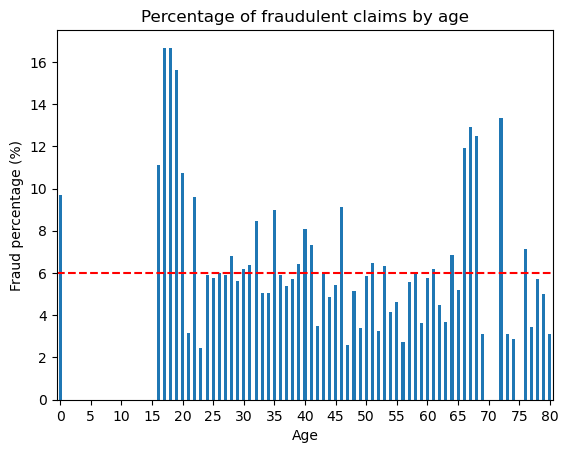

In [303]:
fraud_percentage_age.plot(kind="bar")

plt.xlabel("Age")
plt.ylabel("Fraud percentage (%)")
plt.title("Percentage of fraudulent claims by age")

plt.xticks(
    ticks=range(0, 81, 5),
    labels=range(0, 81, 5),
    rotation=0
)

plt.axhline(y=6, linestyle="--", color="red")

plt.show()

Fraud is most frequently detected among teenagers and retired seniors. Teenagers have weak financial power as they have not yet started their economic activities, and retired seniors experience weakened financial power post-retirement. Considering these points, there seems to be a correlation between financial power and fraud.

Text(0.5, 1.0, 'Age distribution')

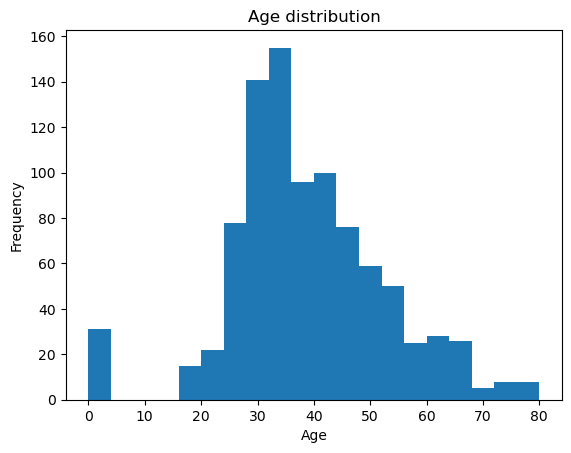

In [257]:
plt.hist(fraud["Age"], bins=20)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age distribution")

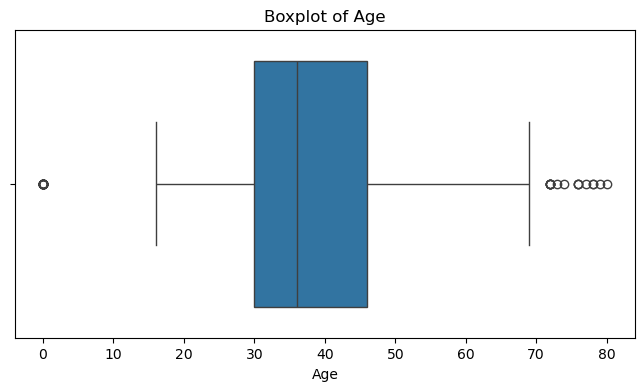

In [258]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=fraud["Age"])

plt.title("Boxplot of Age")
plt.show()

In [304]:
(fraud["Age"]==0).sum()

np.int64(31)

Many claims with "Age" = 0, we can't drop them. Since it is a numerical feature, we replace it with a measure of central tendency.
The median is more robust to outliers because extreme values have little effect on it.
The mean can be pulled up or down by extreme ages, making the imputed value less representative.

In [308]:
median_age = raw_data.Age[raw_data["Age"] != 0].median()
mean_age = raw_data.Age[raw_data["Age"] != 0].mean()
print(median_age)
print(mean_age)

39.0
40.700331125827816


In [307]:
clean_data_1.loc[clean_data_1["Age"] == 0, "Age"] = median_age

### Feature "Sex"

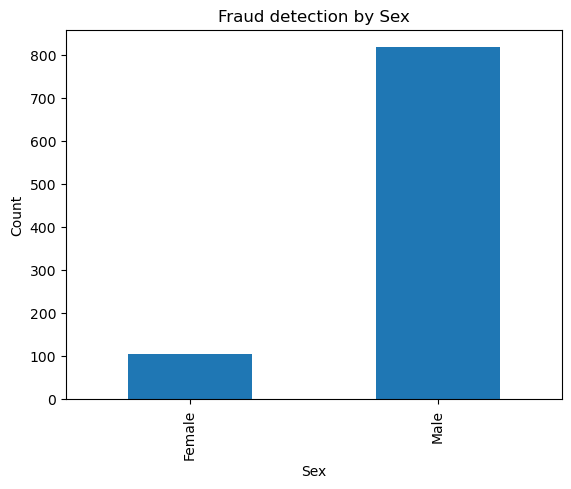

In [262]:
fraud["Sex"].value_counts().sort_values().plot(kind="bar")

plt.xlabel("Sex")
plt.ylabel("Count")
plt.title("Fraud detection by Sex")
plt.show()

These results suggest that males are significantly more likely to be involved in detected fraud cases compared to females. However, this should be interpreted with some caution, as there are also more male drivers than female drivers in the dataset. As a result, males generate a higher number of claims overall, which can naturally lead to a higher absolute number of detected fraud cases.

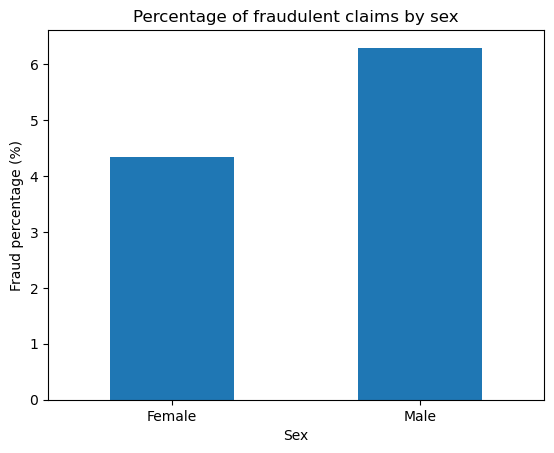

In [196]:
fraud_percentage_sex = (
    raw_data.groupby("Sex")["FraudFound_P"]
    .mean()
    .mul(100)
)
fraud_percentage_sex.plot(kind="bar")

plt.xlabel("Sex")
plt.ylabel("Fraud percentage (%)")
plt.title("Percentage of fraudulent claims by sex")
plt.xticks(rotation=0)
plt.show()

After studying percentages , males have a higher fraud rate.

### Feature "Make"

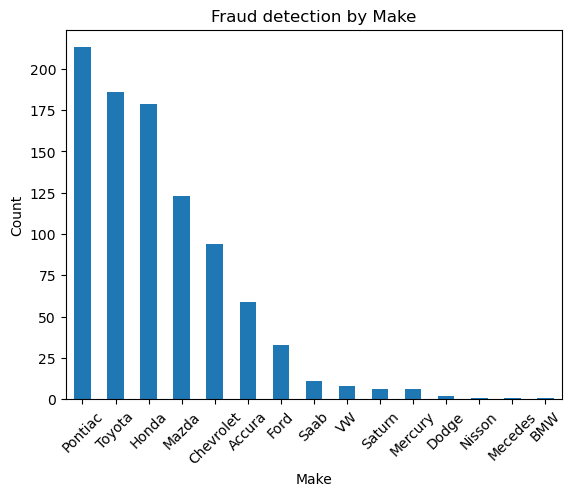

In [195]:
fraud["Make"].value_counts().plot(kind="bar")

plt.xlabel("Make")
plt.ylabel("Count")
plt.title("Fraud detection by Make")
plt.xticks(rotation=45)
plt.show()

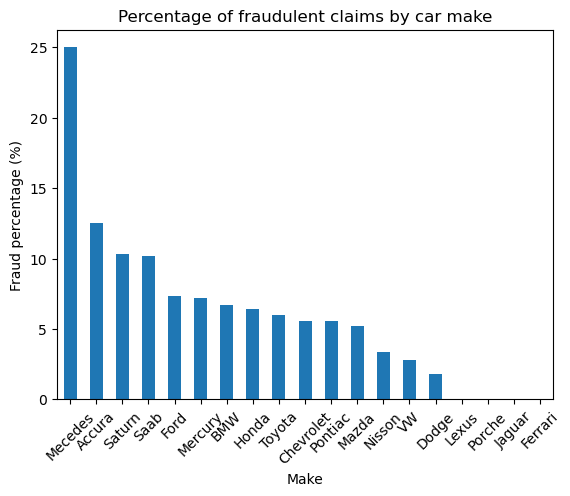

In [ ]:
fraud_percentage_make = (
    raw_data.groupby("Make")["FraudFound_P"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

fraud_percentage_make.plot(kind="bar")

plt.xlabel("Make")
plt.ylabel("Fraud percentage (%)")
plt.title("Percentage of fraudulent claims by car make")
plt.xticks(rotation=45)
plt.show()

In [188]:
make_analysis = raw_data.groupby("Make").agg(
    Total_Claims=("FraudFound_P", "count"),
    Fraudulent_Claims=("FraudFound_P", "sum"),
    Fraud_Percentage=("FraudFound_P", "mean")
)

make_analysis["Fraud_Percentage"] *= 100

make_analysis.sort_values(
    "Fraud_Percentage",
    ascending=False
)

,Total_Claims,Fraudulent_Claims,Fraud_Percentage
Make,,,
Mecedes,4,1,25.000000
Accura,472,59,12.500000
Saturn,58,6,10.344828
Saab,108,11,10.185185
Ford,450,33,7.333333
Mercury,83,6,7.228916
BMW,15,1,6.666667
Honda,2801,179,6.390575
Toyota,3121,186,5.959628


For the Make variable, it is more informative to analyze the percentage of fraudulent claims within each car brand rather than only the absolute number of fraudulent claims. A brand may have a high number of fraud cases simply because it has a larger number of total claims. By calculating the fraud rate for each make, we can compare brands more fairly and identify whether certain car brands are associated with a higher proportion of fraudulent claims.

However, fraud percentages should be interpreted carefully when a car make has very few observations. For example, Mercedes shows a fraud rate of 25%, but this is based on only 4 total claims, with 1 fraudulent case. Because of this small sample size, the percentage is not very reliable and may exaggerate the apparent fraud risk compared with brands that have a much larger number of claims.

On the other hand, the Porche, Lexus, Jaguar, Ferrari owners have never been reported for fraud; all the four make are "High-End"

### Target Balance

In [309]:
target_count = raw_data.FraudFound_P.value_counts().reset_index()
target_count.columns = ["FraudFound_P", "Count"]
target_count

,FraudFound_P,Count
0,0,14497
1,1,923


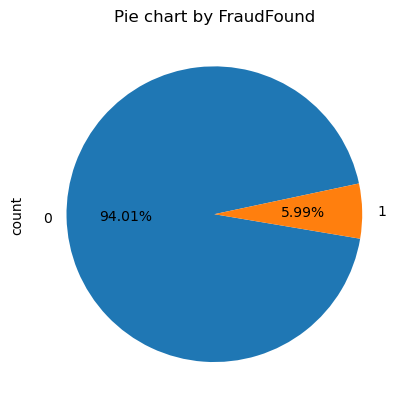

In [310]:
fraud_freq = raw_data.FraudFound_P.value_counts()
fraud_freq.plot.pie(autopct='%1.2f%%' ,startangle=12)
plt.title("Pie chart by FraudFound")
plt.show()

The Target Variable "Fraud_Found_P" is highly imbalanced

Issues Caused by Imbalanced Target Variable

Model Bias: The model may become biased towards the majority class, leading to poor performance on the minority class.

Misleading Metrics: Metrics like accuracy can be misleading, as high accuracy can be achieved by simply predicting the majority class.

Solutions: 
- use precision-recall and f1 score metrics.
  In this imbalanced dataset, we will use **recall and precision** as our main evaluation metrics, with a stronger focus on **recall**. In our case, a false negative for a fraudulent claim is more costly than a false positive. In other words, if the model predicts that a claim is not fraudulent when it actually is, the financial impact can be significant. This is more critical than incorrectly flagging a legitimate claim as fraudulent, which would mainly require further investigation.

- balance the dataset

### Chi-square tests
Tests the independence of two categorical variables by comparing observed frequencies to expected frequencies.

- The chi-square test is a statistical test used to **determine whether there is a significant association between two categorical variables**.
- Interpretation: if p-value < 0.05, this suggests that there is a significant association between the categorical variables. P-value >= 0.05, indicates that there is not enough evidence to conclude a significant association between the variables.


In [311]:
from scipy.stats import chi2_contingency
crosstab_result = pd.crosstab(raw_data.PolicyType,raw_data.BasePolicy)
crosstab_result

BasePolicy,All Perils,Collision,Liability
PolicyType,,,
Sedan - All Perils,4087,0,0
Sedan - Collision,0,5584,0
Sedan - Liability,0,0,4987
Sport - All Perils,22,0,0
Sport - Collision,0,348,0
Sport - Liability,0,0,1
Utility - All Perils,340,0,0
Utility - Collision,0,30,0
Utility - Liability,0,0,21


In [266]:
_, chi2_pvalue, _, _  = chi2_contingency(crosstab_result)
a,b,c,d=chi2_contingency(crosstab_result)
float(chi2_pvalue)

0.0

In [267]:
float(chi2_pvalue) < 0.05

True

p-value< 0.05, we reject the hyphoteshis that the two categorical features are independet, this implies that there's a significant association between PolicyType and BasePolicy. we do have correlation between them

### Cramér's V

While the Chi-square test informs us about the independence of two categorical variables, Cramér's V measures the strength of the association between them.

- Cramer's V is a measure of association used to **quantify the strength of the relationship between categorical variables**.
- Interpretation: Cramer's V ranges from 0 to 1, where **0 indicates no association, and 1 represents a perfect association between the variables**. A higher value of Cramer's V indicates a stronger relationship between the categorical variables.


In [268]:
from scipy.stats.contingency import association
# Computing the association between variables in 'crosstab_result' using the "cramer" method
association(crosstab_result, method='cramer')

0.9999999999999999

### Cramér’s V Interpretation Guide (Cohen's Conventions)

| Cramér’s V | Strength of Association   |
|------------|----------------------------|
| 0.00–0.10  | Negligible / Very Weak     |
| 0.10–0.20  | Weak                       |
| 0.20–0.30  | Moderate                   |
| 0.30–0.50  | Strong                     |
| > 0.50     | Very Strong                |


Very strong relationship between them. Final decision, to drop PolicyType.

In [312]:
clean_data_1.drop(columns=["PolicyType"], inplace=True)

In [314]:
clean_data_1.head()

,Month,Make,AccidentArea,Sex,MaritalStatus,Age,Fault,VehicleCategory,VehiclePrice,FraudFound_P,RepNumber,Deductible,DriverRating,Days_Policy_Accident,Days_Policy_Claim,PastNumberOfClaims,AgeOfVehicle,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,Honda,Urban,Female,Single,21,Policy Holder,Sport,more than 69000,0,12,300,1,more than 30,more than 30,none,3 years,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,Honda,Urban,Male,Single,34,Policy Holder,Sport,more than 69000,0,15,400,4,more than 30,more than 30,none,6 years,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,Honda,Urban,Male,Married,47,Policy Holder,Sport,more than 69000,0,7,400,3,more than 30,more than 30,1,7 years,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,Toyota,Rural,Male,Married,65,Third Party,Sport,20000 to 29000,0,4,400,2,more than 30,more than 30,1,more than 7,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,Honda,Urban,Female,Single,27,Third Party,Sport,more than 69000,0,3,400,1,more than 30,more than 30,none,5 years,No,No,External,none,no change,1 vehicle,1994,Collision


Days_Policy_Accident vs Days_Policy_Claim

In [ ]:
clean_data_1.Days_Policy_Claim.value_counts()

Days_Policy_Claim
more than 30    15342
15 to 30           56
8 to 15            21
none                1
Name: count, dtype: int64

In [ ]:
clean_data_1.Days_Policy_Accident.value_counts()

Days_Policy_Accident
more than 30    15247
none               55
8 to 15            55
15 to 30           49
1 to 7             14
Name: count, dtype: int64

In [283]:
crosstab_result2 = pd.crosstab(clean_data_1.Days_Policy_Accident,clean_data_1.Days_Policy_Claim)
_, chi2_pvalue, _, _  = chi2_contingency(crosstab_result2)
a,b,c,d=chi2_contingency(crosstab_result2)
float(chi2_pvalue)

0.0

In [282]:
association(crosstab_result2, method='cramer')

0.4073286752092501

Although Days_Policy_Accident and Days_Policy_Claim are strongly related, we should not automatically drop either variable because they represent different stages of the insurance claim process. Days_Policy_Accident measures the time between policy inception and the accident, while Days_Policy_Claim measures the time between policy inception and the claim being reported. From a fraud detection perspective, both can contain useful information, since an accident occurring shortly after policy inception and a delayed claim submission may indicate different types of suspicious behavior. Therefore, even with a strong relationship between them, keeping both variables can preserve potentially relevant predictive information for the model.

# Data preprocessing

Label Encoding

In [315]:
binary_columns = [col for col in clean_data_1.columns if clean_data_1[col].nunique() == 2 and col != 'FraudFound_P']
binary_columns

['AccidentArea',
 'Sex',
 'Fault',
 'PoliceReportFiled',
 'WitnessPresent',
 'AgentType']

In [316]:
le = LabelEncoder()

for col  in binary_columns:
    clean_data_1[col] = le.fit_transform(clean_data_1[col])
    print('Label Mapping: ', dict(zip(le.classes_, le.transform(le.classes_))))

Label Mapping:  {'Rural': np.int64(0), 'Urban': np.int64(1)}
Label Mapping:  {'Female': np.int64(0), 'Male': np.int64(1)}
Label Mapping:  {'Policy Holder': np.int64(0), 'Third Party': np.int64(1)}
Label Mapping:  {'No': np.int64(0), 'Yes': np.int64(1)}
Label Mapping:  {'No': np.int64(0), 'Yes': np.int64(1)}
Label Mapping:  {'External': np.int64(0), 'Internal': np.int64(1)}


In [317]:
vehicleprice_label = {'less than 20000': 0, '20000 to 29000': 1,  '30000 to 39000': 2, '40000 to 59000': 3, '60000 to 69000': 4, 'more than 69000': 5}
ageofvehicle_label = {'new': 0, '2 years': 1, '3 years': 2, '4 years': 3, '5 years': 4, '6 years': 5, '7 years': 6, 'more than 7': 7}
dayspolacc_label = {'none': 0, '1 to 7': 1, '8 to 15': 2, '15 to 30': 3, 'more than 30': 4}
dayspolcla_label = {'none': 0, '8 to 15': 2, '15 to 30': 3, 'more than 30': 4}
month_label = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}
pastnumcla_label = {'none': 0, '1': 1, '2 to 4': 2, 'more than 4': 3}
numberofsup_label = {'none': 0, '1 to 2': 1, '3 to 5': 2, 'more than 5': 3}
addresschange_label = {'no change': 0, 'under 6 months': 1, '1 year': 2, '2 to 3 years': 3, '4 to 8 years': 4}
numberofcars_label = {'1 vehicle': 0, '2 vehicles': 1, '3 to 4': 2, '5 to 8': 3, 'more than 8': 4}

In [318]:
columns_labels = {
    'VehiclePrice': vehicleprice_label,
    'AgeOfVehicle': ageofvehicle_label,
    'Days_Policy_Accident': dayspolacc_label,
    'Days_Policy_Claim': dayspolcla_label,
    'Month': month_label,
    'PastNumberOfClaims': pastnumcla_label,
    'NumberOfSuppliments': numberofsup_label,
    'AddressChange_Claim': addresschange_label,
    'NumberOfCars': numberofcars_label
}

for column, label_map in columns_labels.items():
    clean_data_1[column] = clean_data_1[column].map(label_map)


One hot encoding

In [323]:
clean_data_1.columns

Index(['Month', 'Make', 'AccidentArea', 'Sex', 'MaritalStatus', 'Age', 'Fault',
       'VehicleCategory', 'VehiclePrice', 'FraudFound_P', 'RepNumber',
       'Deductible', 'DriverRating', 'Days_Policy_Accident',
       'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle',
       'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year',
       'BasePolicy'],
      dtype='object')

In [327]:
clean_data_2 = pd.get_dummies(clean_data_1, columns=["Make","MaritalStatus","VehicleCategory","BasePolicy"], drop_first=True)

In [328]:
clean_data_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 46 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Month                    15420 non-null  int64
 1   AccidentArea             15420 non-null  int64
 2   Sex                      15420 non-null  int64
 3   Age                      15420 non-null  int64
 4   Fault                    15420 non-null  int64
 5   VehiclePrice             15420 non-null  int64
 6   FraudFound_P             15420 non-null  int64
 7   RepNumber                15420 non-null  int64
 8   Deductible               15420 non-null  int64
 9   DriverRating             15420 non-null  int64
 10  Days_Policy_Accident     15420 non-null  int64
 11  Days_Policy_Claim        15420 non-null  int64
 12  PastNumberOfClaims       15420 non-null  int64
 13  AgeOfVehicle             15420 non-null  int64
 14  PoliceReportFiled        15420 non-null  int64
 15  Wi

# Modeling, Prediction and Evaluation

#### Explore the data from an bird's-eye view.

You should already been very familiar with the procedures now so we won't provide the instructions step by step. Reflect on what you did in the previous labs and explore the dataset.

Things you'll be looking for:

* What the dataset looks like?
* What are the data types?
* Which columns contain the features of the websites?
* Which column contains the feature we will predict? What is the code standing for benign vs malicious websites?
* Do we need to transform any of the columns from categorical to ordinal values? If so what are these columns?

Feel free to add additional cells for your explorations. Make sure to comment what you find out.


There is no missing values.
Numerical and categorical features


In [ ]:
type(websites)

pandas.core.frame.DataFrame

In [4]:
websites.head()

,URL,URL_LENGTH,NUMBER_SPECIAL_CHARACTERS,CHARSET,SERVER,CONTENT_LENGTH,WHOIS_COUNTRY,WHOIS_STATEPRO,WHOIS_REGDATE,WHOIS_UPDATED_DATE,...,DIST_REMOTE_TCP_PORT,REMOTE_IPS,APP_BYTES,SOURCE_APP_PACKETS,REMOTE_APP_PACKETS,SOURCE_APP_BYTES,REMOTE_APP_BYTES,APP_PACKETS,DNS_QUERY_TIMES,Type
0,M0_109,16,7,iso-8859-1,nginx,263.0,NaN,NaN,10/10/2015 18:21,NaN,...,0,2,700,9,10,1153,832,9,2.0,1
1,B0_2314,16,6,UTF-8,Apache/2.4.10,15087.0,NaN,NaN,NaN,NaN,...,7,4,1230,17,19,1265,1230,17,0.0,0
2,B0_911,16,6,us-ascii,Microsoft-HTTPAPI/2.0,324.0,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0.0,0
3,B0_113,17,6,ISO-8859-1,nginx,162.0,US,AK,7/10/1997 4:00,12/09/2013 0:45,...,22,3,3812,39,37,18784,4380,39,8.0,0
4,B0_403,17,6,UTF-8,NaN,124140.0,US,TX,12/05/1996 0:00,11/04/2017 0:00,...,2,5,4278,61,62,129889,4586,61,4.0,0


In [5]:
websites.shape

(1781, 21)

In [6]:
websites.CHARSET.nunique()

8

In [7]:
websites.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1781 entries, 0 to 1780
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   URL                        1781 non-null   object 
 1   URL_LENGTH                 1781 non-null   int64  
 2   NUMBER_SPECIAL_CHARACTERS  1781 non-null   int64  
 3   CHARSET                    1774 non-null   object 
 4   SERVER                     1605 non-null   object 
 5   CONTENT_LENGTH             969 non-null    float64
 6   WHOIS_COUNTRY              1475 non-null   object 
 7   WHOIS_STATEPRO             1419 non-null   object 
 8   WHOIS_REGDATE              1654 non-null   object 
 9   WHOIS_UPDATED_DATE         1642 non-null   object 
 10  TCP_CONVERSATION_EXCHANGE  1781 non-null   int64  
 11  DIST_REMOTE_TCP_PORT       1781 non-null   int64  
 12  REMOTE_IPS                 1781 non-null   int64  
 13  APP_BYTES                  1781 non-null   int64

In [8]:
features = [col for col in websites.columns if col != 'Type']
print(f'Columns containing features are:\n {features}')

Columns containing features are:
 ['URL', 'URL_LENGTH', 'NUMBER_SPECIAL_CHARACTERS', 'CHARSET', 'SERVER', 'CONTENT_LENGTH', 'WHOIS_COUNTRY', 'WHOIS_STATEPRO', 'WHOIS_REGDATE', 'WHOIS_UPDATED_DATE', 'TCP_CONVERSATION_EXCHANGE', 'DIST_REMOTE_TCP_PORT', 'REMOTE_IPS', 'APP_BYTES', 'SOURCE_APP_PACKETS', 'REMOTE_APP_PACKETS', 'SOURCE_APP_BYTES', 'REMOTE_APP_BYTES', 'APP_PACKETS', 'DNS_QUERY_TIMES']


In [9]:
target = websites.iloc[:, -1]
target


0       1
1       0
2       0
3       0
4       0
       ..
1776    1
1777    1
1778    0
1779    0
1780    0
Name: Type, Length: 1781, dtype: int64

In [10]:

target.unique()

array([1, 0])

In [85]:
websites.info()

<class 'pandas.DataFrame'>
RangeIndex: 1781 entries, 0 to 1780
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   URL                        1781 non-null   str    
 1   URL_LENGTH                 1781 non-null   int64  
 2   NUMBER_SPECIAL_CHARACTERS  1781 non-null   int64  
 3   CHARSET                    1774 non-null   str    
 4   SERVER                     1605 non-null   str    
 5   CONTENT_LENGTH             969 non-null    float64
 6   WHOIS_COUNTRY              1475 non-null   str    
 7   WHOIS_STATEPRO             1419 non-null   str    
 8   WHOIS_REGDATE              1654 non-null   str    
 9   WHOIS_UPDATED_DATE         1642 non-null   str    
 10  TCP_CONVERSATION_EXCHANGE  1781 non-null   int64  
 11  DIST_REMOTE_TCP_PORT       1781 non-null   int64  
 12  REMOTE_IPS                 1781 non-null   int64  
 13  APP_BYTES                  1781 non-null   int64  
 14  SOU

In [86]:
# Do we need to transform any of the columns from categorical to ordinal values? If so what are these columns?
# Ideally we need to transform all the object columns from categorical to ordinal values inorder for the models to identify them as it doesnt identifies strings in the categorical columns.

#### Next, evaluate if the columns in this dataset are strongly correlated.

In the Mushroom supervised learning lab we did recently, we mentioned we are concerned if our dataset has strongly correlated columns because if it is the case we need to choose certain ML algorithms instead of others. We need to evaluate this for our dataset now.

Luckily, most of the columns in this dataset are ordinal which makes things a lot easier for us. In the next cells below, evaluate the level of collinearity of the data.

We provide some general directions for you to consult in order to complete this step:

1. You will create a correlation matrix using the numeric columns in the dataset.

1. Create a heatmap using `seaborn` to visualize which columns have high collinearity.

1. Comment on which columns you might need to remove due to high collinearity.

In [11]:
numerical_columns = websites.select_dtypes(include='number')
numerical_columns


,URL_LENGTH,NUMBER_SPECIAL_CHARACTERS,CONTENT_LENGTH,TCP_CONVERSATION_EXCHANGE,DIST_REMOTE_TCP_PORT,REMOTE_IPS,APP_BYTES,SOURCE_APP_PACKETS,REMOTE_APP_PACKETS,SOURCE_APP_BYTES,REMOTE_APP_BYTES,APP_PACKETS,DNS_QUERY_TIMES,Type
0,16,7,263.0,7,0,2,700,9,10,1153,832,9,2.0,1
1,16,6,15087.0,17,7,4,1230,17,19,1265,1230,17,0.0,0
2,16,6,324.0,0,0,0,0,0,0,0,0,0,0.0,0
3,17,6,162.0,31,22,3,3812,39,37,18784,4380,39,8.0,0
4,17,6,124140.0,57,2,5,4278,61,62,129889,4586,61,4.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1776,194,16,NaN,0,0,0,0,0,3,186,0,0,0.0,1
1777,198,17,NaN,0,0,0,0,0,2,124,0,0,0.0,1
1778,201,34,8904.0,83,2,6,6631,87,89,132181,6945,87,4.0,0
1779,234,34,NaN,0,0,0,0,0,0,0,0,0,0.0,0


In [12]:
corr = numerical_columns.corr()
corr

,URL_LENGTH,NUMBER_SPECIAL_CHARACTERS,CONTENT_LENGTH,TCP_CONVERSATION_EXCHANGE,DIST_REMOTE_TCP_PORT,REMOTE_IPS,APP_BYTES,SOURCE_APP_PACKETS,REMOTE_APP_PACKETS,SOURCE_APP_BYTES,REMOTE_APP_BYTES,APP_PACKETS,DNS_QUERY_TIMES,Type
URL_LENGTH,1.000000,0.917986,0.129745,-0.038407,-0.039839,-0.046367,-0.026446,-0.042264,-0.033779,-0.014857,-0.026686,-0.042264,-0.068582,0.162104
NUMBER_SPECIAL_CHARACTERS,0.917986,1.000000,0.214225,-0.037459,-0.042619,-0.047103,-0.023914,-0.040096,-0.030597,-0.014376,-0.024098,-0.040096,-0.050048,0.280897
CONTENT_LENGTH,0.129745,0.214225,1.000000,0.078451,-0.000381,0.004774,0.051202,0.074142,0.091077,0.100094,0.047595,0.074142,-0.045644,-0.090852
TCP_CONVERSATION_EXCHANGE,-0.038407,-0.037459,0.078451,1.000000,0.555188,0.331080,0.457320,0.997796,0.990848,0.865580,0.458702,0.997796,0.349832,-0.040202
DIST_REMOTE_TCP_PORT,-0.039839,-0.042619,-0.000381,0.555188,1.000000,0.210188,0.780238,0.558612,0.591188,0.313359,0.781212,0.558612,0.259942,-0.082925
REMOTE_IPS,-0.046367,-0.047103,0.004774,0.331080,0.210188,1.000000,0.023126,0.361104,0.304683,0.171651,0.025324,0.361104,0.548189,-0.078783
APP_BYTES,-0.026446,-0.023914,0.051202,0.457320,0.780238,0.023126,1.000000,0.445822,0.468999,0.074464,0.999992,0.445822,0.012221,-0.011262
SOURCE_APP_PACKETS,-0.042264,-0.040096,0.074142,0.997796,0.558612,0.361104,0.445822,1.000000,0.989285,0.857495,0.447448,1.000000,0.410843,-0.034414
REMOTE_APP_PACKETS,-0.033779,-0.030597,0.091077,0.990848,0.591188,0.304683,0.468999,0.989285,1.000000,0.880555,0.470401,0.989285,0.355716,-0.032897
SOURCE_APP_BYTES,-0.014857,-0.014376,0.100094,0.865580,0.313359,0.171651,0.074464,0.857495,0.880555,1.000000,0.075328,0.857495,0.215285,-0.043852


In [13]:
import matplotlib.pyplot as plt
import seaborn as sn

In [14]:
mask = np.triu(np.ones_like(corr, dtype=bool))

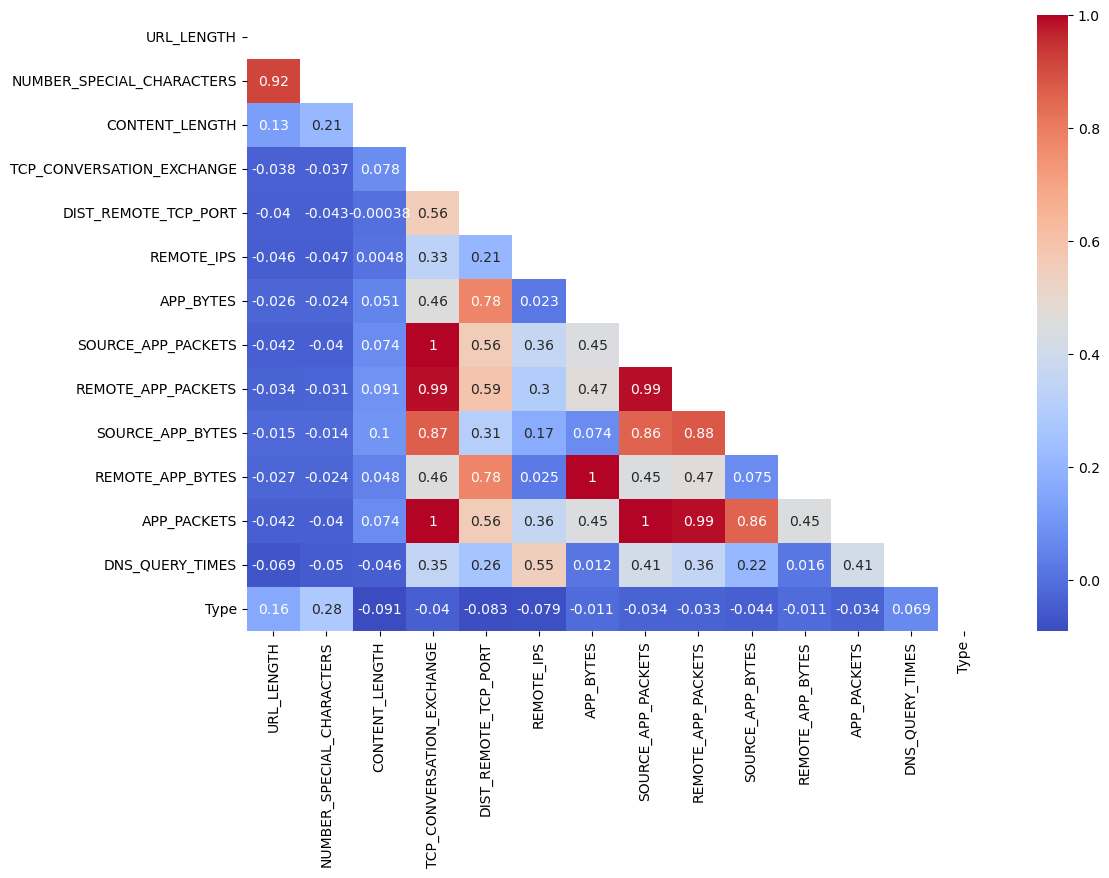

In [15]:
plt.figure(figsize=(12,8))
sn.heatmap(data=corr, mask=mask, annot=True, cmap='coolwarm')
plt.show()

Columns = TCP_Conversation_exchange, Remote_app_packets, and app_packets should be removed due to high colinearity

### This is an example to know the feacture importance using a ML model

In [92]:
#! pip install xgboost

In [16]:
import xgboost as xgb

In [17]:
X = websites._get_numeric_data().drop('Type', axis=1)
y = websites.Type

In [18]:
xgb_model = xgb.XGBClassifier()

In [19]:
xgb_model.fit(X,y)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [20]:
sort_idx = xgb_model.feature_importances_.argsort()

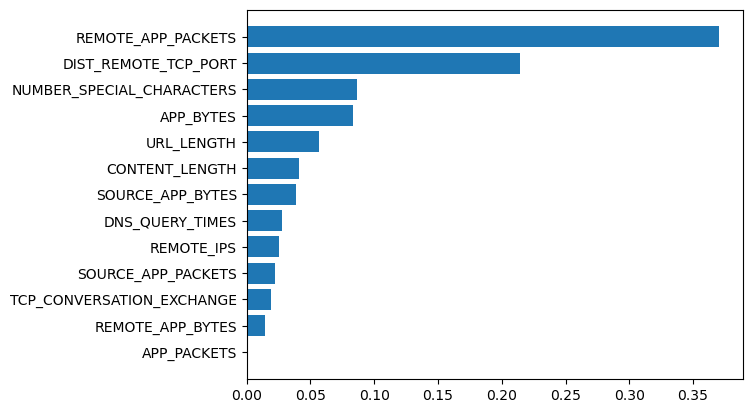

In [21]:
plt.barh(X.columns[sort_idx],xgb_model.feature_importances_[sort_idx])
plt.show();

    In the previous plot we can see the feactures with lower weight in the dataset.

# Challenge 2 - Remove Column Collinearity.

From the heatmap you created, you should have seen at least 3 columns that can be removed due to high collinearity. Remove these columns from the dataset.

Note that you should remove as few columns as you can. You don't have to remove all the columns at once. But instead, try removing one column, then produce the heatmap again to determine if additional columns should be removed. As long as the dataset no longer contains columns that are correlated for over 90%, you can stop. Also, keep in mind when two columns have high collinearity, you only need to remove one of them but not both.

In the cells below, remove as few columns as you can to eliminate the high collinearity in the dataset. Make sure to comment on your way so that the instructional team can learn about your thinking process which allows them to give feedback. At the end, print the heatmap again.

In [22]:
websites.columns

Index(['URL', 'URL_LENGTH', 'NUMBER_SPECIAL_CHARACTERS', 'CHARSET', 'SERVER',
       'CONTENT_LENGTH', 'WHOIS_COUNTRY', 'WHOIS_STATEPRO', 'WHOIS_REGDATE',
       'WHOIS_UPDATED_DATE', 'TCP_CONVERSATION_EXCHANGE',
       'DIST_REMOTE_TCP_PORT', 'REMOTE_IPS', 'APP_BYTES', 'SOURCE_APP_PACKETS',
       'REMOTE_APP_PACKETS', 'SOURCE_APP_BYTES', 'REMOTE_APP_BYTES',
       'APP_PACKETS', 'DNS_QUERY_TIMES', 'Type'],
      dtype='object')

In [23]:
drop_col = ['APP_PACKETS','TCP_CONVERSATION_EXCHANGE','REMOTE_APP_PACKETS', 'APP_BYTES']
numerical_columns = numerical_columns.drop(columns=drop_col)
numerical_columns

,URL_LENGTH,NUMBER_SPECIAL_CHARACTERS,CONTENT_LENGTH,DIST_REMOTE_TCP_PORT,REMOTE_IPS,SOURCE_APP_PACKETS,SOURCE_APP_BYTES,REMOTE_APP_BYTES,DNS_QUERY_TIMES,Type
0,16,7,263.0,0,2,9,1153,832,2.0,1
1,16,6,15087.0,7,4,17,1265,1230,0.0,0
2,16,6,324.0,0,0,0,0,0,0.0,0
3,17,6,162.0,22,3,39,18784,4380,8.0,0
4,17,6,124140.0,2,5,61,129889,4586,4.0,0
...,...,...,...,...,...,...,...,...,...,...
1776,194,16,NaN,0,0,0,186,0,0.0,1
1777,198,17,NaN,0,0,0,124,0,0.0,1
1778,201,34,8904.0,2,6,87,132181,6945,4.0,0
1779,234,34,NaN,0,0,0,0,0,0.0,0


The TCP_CONVERSATION_EXCHANGE column shows high colinearity with 3 other columns. Hence it is removed on order to remove as less columns as possible while keeping high colinearity minimal. same is the case APP_PACKETS and REMOTE_APP_PACKETS.

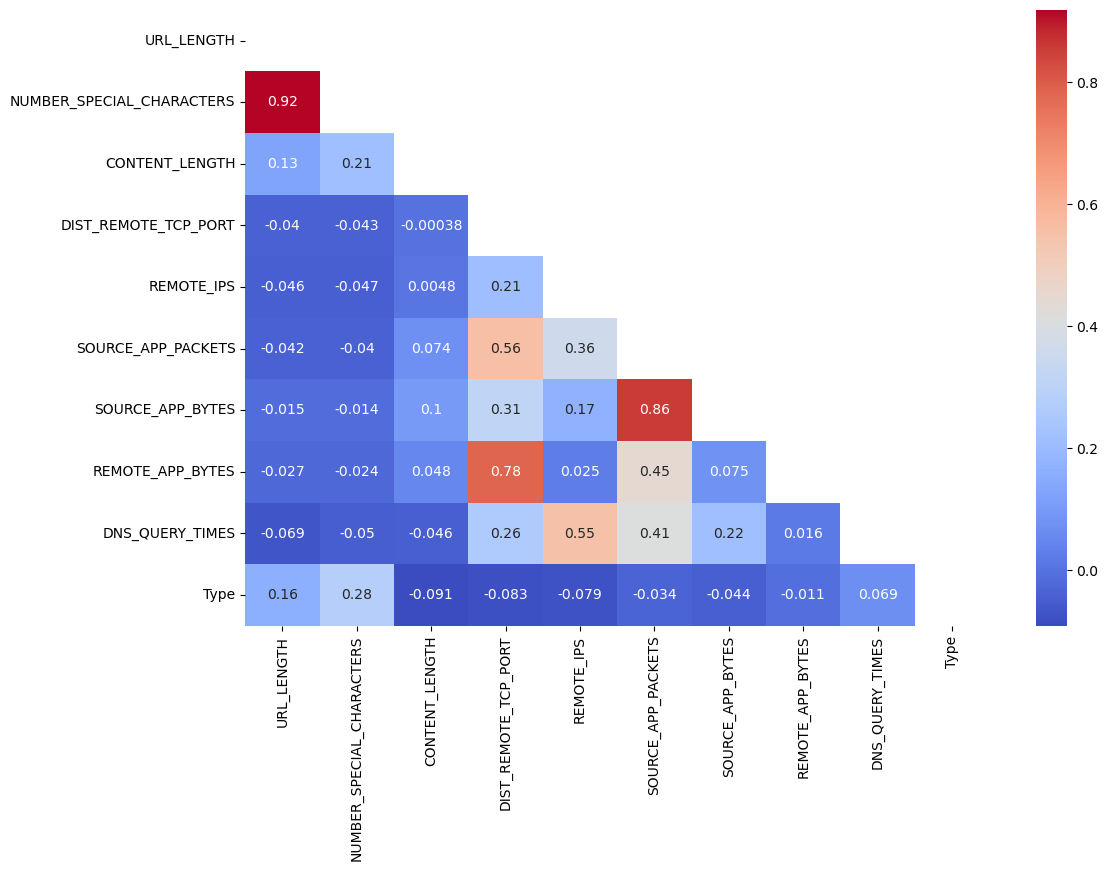

In [24]:
corr_new = numerical_columns.corr()

mask = np.triu(np.ones_like(corr_new, dtype=bool))

plt.figure(figsize=(12,8))
sn.heatmap(data=corr_new, mask=mask, annot=True, cmap='coolwarm')
plt.show()

# Challenge 3 - Handle Missing Values

The next step would be handling missing values. **We start by examining the number of missing values in each column, which you will do in the next cell.**

In [25]:
numerical_columns

,URL_LENGTH,NUMBER_SPECIAL_CHARACTERS,CONTENT_LENGTH,DIST_REMOTE_TCP_PORT,REMOTE_IPS,SOURCE_APP_PACKETS,SOURCE_APP_BYTES,REMOTE_APP_BYTES,DNS_QUERY_TIMES,Type
0,16,7,263.0,0,2,9,1153,832,2.0,1
1,16,6,15087.0,7,4,17,1265,1230,0.0,0
2,16,6,324.0,0,0,0,0,0,0.0,0
3,17,6,162.0,22,3,39,18784,4380,8.0,0
4,17,6,124140.0,2,5,61,129889,4586,4.0,0
...,...,...,...,...,...,...,...,...,...,...
1776,194,16,NaN,0,0,0,186,0,0.0,1
1777,198,17,NaN,0,0,0,124,0,0.0,1
1778,201,34,8904.0,2,6,87,132181,6945,4.0,0
1779,234,34,NaN,0,0,0,0,0,0.0,0


In [26]:
numerical_columns.isna().sum()

URL_LENGTH                     0
NUMBER_SPECIAL_CHARACTERS      0
CONTENT_LENGTH               812
DIST_REMOTE_TCP_PORT           0
REMOTE_IPS                     0
SOURCE_APP_PACKETS             0
SOURCE_APP_BYTES               0
REMOTE_APP_BYTES               0
DNS_QUERY_TIMES                1
Type                           0
dtype: int64

In [104]:
(812/1781)*100

45.59236384053902

In [27]:
numerical_columns.CONTENT_LENGTH.describe()

count       969.000000
mean      11726.927761
std       36391.809051
min           0.000000
25%         324.000000
50%        1853.000000
75%       11323.000000
max      649263.000000
Name: CONTENT_LENGTH, dtype: float64

In [28]:
websites['CONTENT_LENGTH'].corr(websites['Type'])

np.float64(-0.09085169100261939)

In [29]:
numerical_columns = numerical_columns.drop(columns=['CONTENT_LENGTH'])
numerical_columns.isna().sum()

URL_LENGTH                   0
NUMBER_SPECIAL_CHARACTERS    0
DIST_REMOTE_TCP_PORT         0
REMOTE_IPS                   0
SOURCE_APP_PACKETS           0
SOURCE_APP_BYTES             0
REMOTE_APP_BYTES             0
DNS_QUERY_TIMES              1
Type                         0
dtype: int64

In [30]:
numerical_columns = numerical_columns.dropna(subset=['DNS_QUERY_TIMES'])
numerical_columns.isna().sum()

URL_LENGTH                   0
NUMBER_SPECIAL_CHARACTERS    0
DIST_REMOTE_TCP_PORT         0
REMOTE_IPS                   0
SOURCE_APP_PACKETS           0
SOURCE_APP_BYTES             0
REMOTE_APP_BYTES             0
DNS_QUERY_TIMES              0
Type                         0
dtype: int64

In [31]:
websites =websites.loc[numerical_columns.index]

websites[numerical_columns.columns] = numerical_columns

In [32]:
websites.isna().sum()

URL                            0
URL_LENGTH                     0
NUMBER_SPECIAL_CHARACTERS      0
CHARSET                        7
SERVER                       176
CONTENT_LENGTH               812
WHOIS_COUNTRY                306
WHOIS_STATEPRO               362
WHOIS_REGDATE                127
WHOIS_UPDATED_DATE           139
TCP_CONVERSATION_EXCHANGE      0
DIST_REMOTE_TCP_PORT           0
REMOTE_IPS                     0
APP_BYTES                      0
SOURCE_APP_PACKETS             0
REMOTE_APP_PACKETS             0
SOURCE_APP_BYTES               0
REMOTE_APP_BYTES               0
APP_PACKETS                    0
DNS_QUERY_TIMES                0
Type                           0
dtype: int64

In [33]:
websites = websites.dropna(subset=['CHARSET', 'SERVER', 'WHOIS_COUNTRY', 'WHOIS_STATEPRO', 'WHOIS_REGDATE', 'WHOIS_UPDATED_DATE', 'DNS_QUERY_TIMES'])
websites = websites.drop(columns= 'CONTENT_LENGTH')

#### Again, examine the number of missing values in each column. 

    If all cleaned, proceed. Otherwise, go back and do more cleaning.

In [34]:
websites.isna().sum()

URL                          0
URL_LENGTH                   0
NUMBER_SPECIAL_CHARACTERS    0
CHARSET                      0
SERVER                       0
WHOIS_COUNTRY                0
WHOIS_STATEPRO               0
WHOIS_REGDATE                0
WHOIS_UPDATED_DATE           0
TCP_CONVERSATION_EXCHANGE    0
DIST_REMOTE_TCP_PORT         0
REMOTE_IPS                   0
APP_BYTES                    0
SOURCE_APP_PACKETS           0
REMOTE_APP_PACKETS           0
SOURCE_APP_BYTES             0
REMOTE_APP_BYTES             0
APP_PACKETS                  0
DNS_QUERY_TIMES              0
Type                         0
dtype: int64

# Challenge 4 - Handle `WHOIS_*` Categorical Data

There are several categorical columns we need to handle. These columns are:

* `URL`
* `CHARSET`
* `SERVER`
* `WHOIS_COUNTRY`
* `WHOIS_STATEPRO`
* `WHOIS_REGDATE`
* `WHOIS_UPDATED_DATE`

How to handle string columns is always case by case. Let's start by working on `WHOIS_COUNTRY`. Your steps are:

1. List out the unique values of `WHOIS_COUNTRY`.
1. Consolidate the country values with consistent country codes. For example, the following values refer to the same country and should use consistent country code:
    * `CY` and `Cyprus`
    * `US` and `us`
    * `SE` and `se`
    * `GB`, `United Kingdom`, and `[u'GB'; u'UK']`

#### In the cells below, fix the country values as intructed above.

In [35]:
websites.WHOIS_COUNTRY.value_counts()

WHOIS_COUNTRY
US                957
CA                 75
ES                 63
AU                 26
PA                 21
GB                 13
JP                 10
CZ                  8
CN                  8
IN                  8
NL                  5
[u'GB'; u'UK']      5
CH                  5
BS                  4
UK                  4
ru                  4
AT                  4
KY                  3
PH                  3
SC                  3
us                  3
HK                  2
UA                  2
UY                  2
KG                  2
SI                  2
RU                  2
TR                  1
UG                  1
PK                  1
IL                  1
DE                  1
SE                  1
IT                  1
NO                  1
BE                  1
BY                  1
AE                  1
IE                  1
LV                  1
Name: count, dtype: int64

In [36]:
websites['WHOIS_COUNTRY'].unique()

array(['US', 'SC', 'RU', 'AU', 'CA', 'PA', 'IN', 'GB', "[u'GB'; u'UK']",
       'NL', 'UG', 'JP', 'CN', 'UK', 'SI', 'ru', 'KY', 'AT', 'CZ', 'PH',
       'LV', 'TR', 'ES', 'us', 'HK', 'UA', 'CH', 'BS', 'PK', 'IL', 'DE',
       'SE', 'IT', 'NO', 'BE', 'BY', 'AE', 'IE', 'UY', 'KG'], dtype=object)

In [37]:
websites.WHOIS_COUNTRY.isna().sum()

np.int64(0)

In [38]:
# Your code here
good_country = {'None':'None', 
                'US':'US', 
                'SC':'SC', 
                'GB':'UK', 
                'UK':'UK', 
                'RU':'RU', 
                'AU':'AU', 
                'CA':'CA',
                'PA':'PA',
                'se':'SE', 
                'IN':'IN',
                'LU':'LU', 
                'TH':'TH', 
                "[u'GB'; u'UK']":'UK', 
                'FR':'FR',
                'NL':'NL',
                'UG':'UG', 
                'JP':'JP', 
                'CN':'CN', 
                'SE':'SE',
                'SI':'SI', 
                'IL':'IL', 
                'ru':'RU', 
                'KY':'KY', 
                'AT':'AT', 
                'CZ':'CZ', 
                'PH':'PH', 
                'BE':'BE', 
                'NO':'NO', 
                'TR':'TR', 
                'LV':'LV',
                'DE':'DE', 
                'ES':'ES', 
                'BR':'BR', 
                'us':'US', 
                'KR':'KR', 
                'HK':'HK', 
                'UA':'UA', 
                'CH':'CH', 
                'United Kingdom':'UK',
                'BS':'BS', 
                'PK':'PK', 
                'IT':'IT', 
                'Cyprus':'CY', 
                'BY':'BY', 
                'AE':'AE', 
                'IE':'IE', 
                'UY':'UY', 
                'KG':'KG'}

websites.WHOIS_COUNTRY = websites.WHOIS_COUNTRY.apply(lambda x : good_country[x])

In [39]:
websites.WHOIS_COUNTRY.unique()

array(['US', 'SC', 'RU', 'AU', 'CA', 'PA', 'IN', 'UK', 'NL', 'UG', 'JP',
       'CN', 'SI', 'KY', 'AT', 'CZ', 'PH', 'LV', 'TR', 'ES', 'HK', 'UA',
       'CH', 'BS', 'PK', 'IL', 'DE', 'SE', 'IT', 'NO', 'BE', 'BY', 'AE',
       'IE', 'UY', 'KG'], dtype=object)

Since we have fixed the country values, can we convert this column to ordinal now?

Not yet. If you reflect on the previous labs how we handle categorical columns, you probably remember we ended up dropping a lot of those columns because there are too many unique values. Too many unique values in a column is not desirable in machine learning because it makes prediction inaccurate. But there are workarounds under certain conditions. One of the fixable conditions is:

#### If a limited number of values account for the majority of data, we can retain these top values and re-label all other rare values.

The `WHOIS_COUNTRY` column happens to be this case. You can verify it by print a bar chart of the `value_counts` in the next cell to verify:

In [40]:
def print_bar_plot(x,y):
    plt.figure(figsize=(15,15))
    plt.bar(x, y)
    plt.xticks(rotation=90)
    return plt.show()

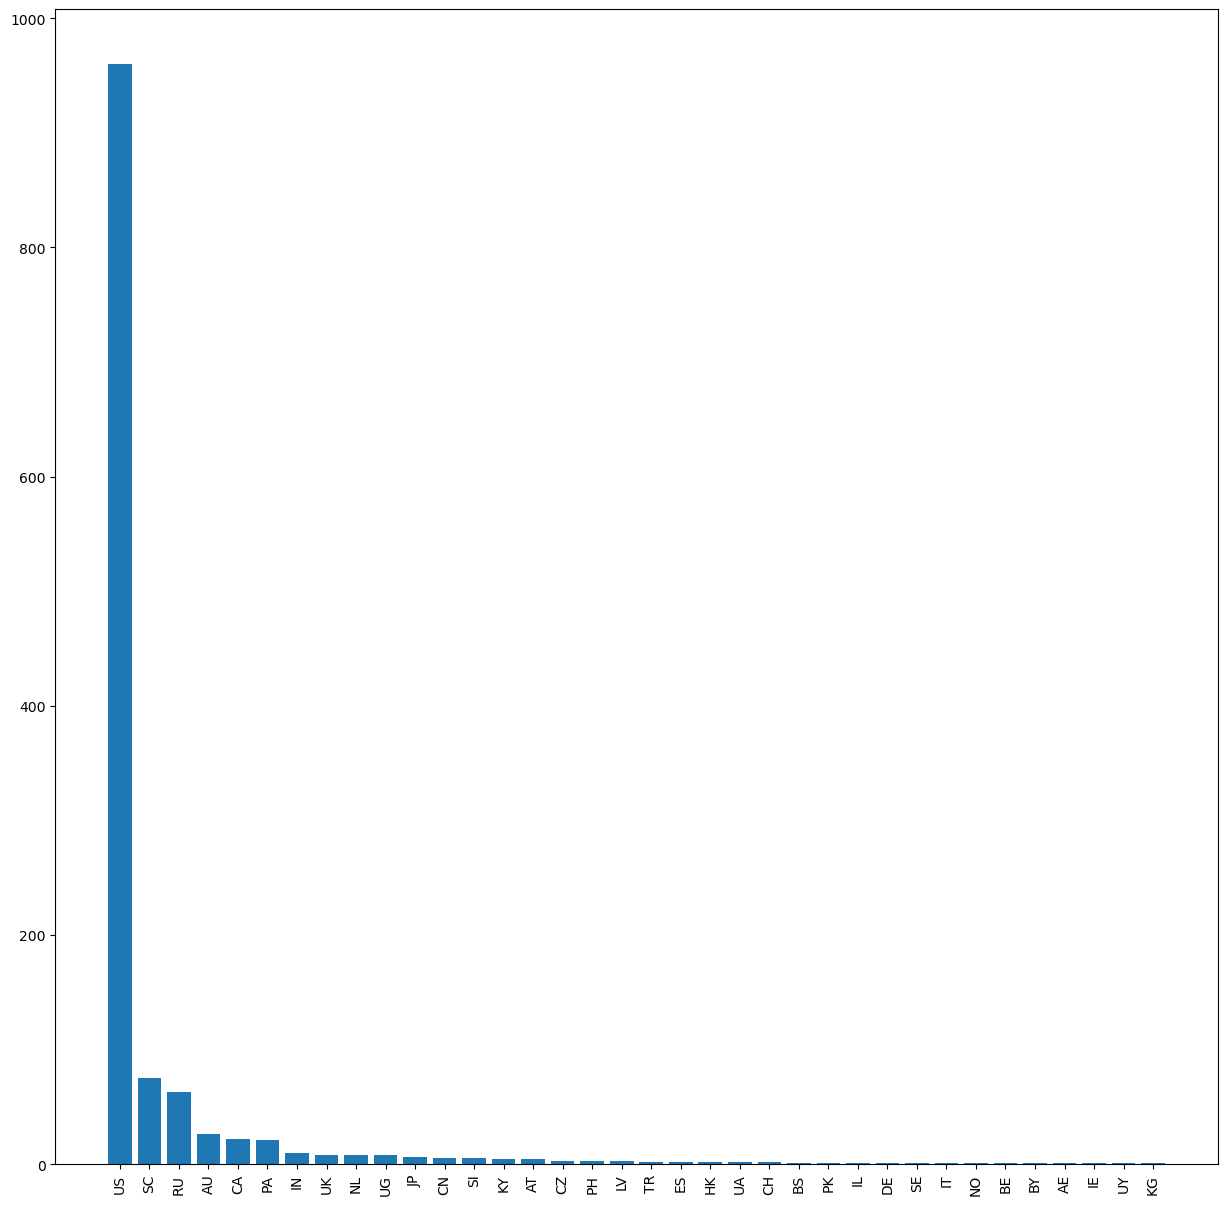

In [41]:
print_bar_plot(websites.WHOIS_COUNTRY.unique(),websites.WHOIS_COUNTRY.value_counts());

#### After verifying, now let's keep the top 10 values of the column and re-label other columns with `OTHER`.

In [42]:
top10 = websites['WHOIS_COUNTRY'].value_counts().head(10).index
top10

Index(['US', 'CA', 'ES', 'AU', 'UK', 'PA', 'JP', 'IN', 'CZ', 'CN'], dtype='object', name='WHOIS_COUNTRY')

In [43]:
websites.WHOIS_COUNTRY = websites.WHOIS_COUNTRY.apply(lambda x: x if x in top10 else 'OTHER')

Now since `WHOIS_COUNTRY` has been re-labelled, we don't need `WHOIS_STATEPRO` any more because the values of the states or provinces may not be relevant any more. We'll drop this column.

In addition, we will also drop `WHOIS_REGDATE` and `WHOIS_UPDATED_DATE`. These are the registration and update dates of the website domains. Not of our concerns.

#### In the next cell, drop `['WHOIS_STATEPRO', 'WHOIS_REGDATE', 'WHOIS_UPDATED_DATE']`.

In [44]:
websites.columns

Index(['URL', 'URL_LENGTH', 'NUMBER_SPECIAL_CHARACTERS', 'CHARSET', 'SERVER',
       'WHOIS_COUNTRY', 'WHOIS_STATEPRO', 'WHOIS_REGDATE',
       'WHOIS_UPDATED_DATE', 'TCP_CONVERSATION_EXCHANGE',
       'DIST_REMOTE_TCP_PORT', 'REMOTE_IPS', 'APP_BYTES', 'SOURCE_APP_PACKETS',
       'REMOTE_APP_PACKETS', 'SOURCE_APP_BYTES', 'REMOTE_APP_BYTES',
       'APP_PACKETS', 'DNS_QUERY_TIMES', 'Type'],
      dtype='object')

In [45]:
websites = websites.drop(columns= ['WHOIS_STATEPRO','WHOIS_REGDATE', 'WHOIS_UPDATED_DATE'])

# Challenge 5 - Handle Remaining Categorical Data & Convert to Ordinal

Now print the `dtypes` of the data again. Besides `WHOIS_COUNTRY` which we already fixed, there should be 3 categorical columns left: `URL`, `CHARSET`, and `SERVER`.

In [124]:
websites.info()

<class 'pandas.DataFrame'>
Index: 1257 entries, 3 to 1780
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   URL                        1257 non-null   str    
 1   URL_LENGTH                 1257 non-null   int64  
 2   NUMBER_SPECIAL_CHARACTERS  1257 non-null   int64  
 3   CHARSET                    1257 non-null   str    
 4   SERVER                     1257 non-null   str    
 5   WHOIS_COUNTRY              1257 non-null   str    
 6   TCP_CONVERSATION_EXCHANGE  1257 non-null   int64  
 7   DIST_REMOTE_TCP_PORT       1257 non-null   int64  
 8   REMOTE_IPS                 1257 non-null   int64  
 9   APP_BYTES                  1257 non-null   int64  
 10  SOURCE_APP_PACKETS         1257 non-null   int64  
 11  REMOTE_APP_PACKETS         1257 non-null   int64  
 12  SOURCE_APP_BYTES           1257 non-null   int64  
 13  REMOTE_APP_BYTES           1257 non-null   int64  
 14  APP_PACK

#### `URL` is easy. We'll simply drop it because it has too many unique values that there's no way for us to consolidate.

In [46]:
websites.URL.nunique()

1257

In [47]:
websites = websites.drop(columns='URL')


In [48]:
websites

,URL_LENGTH,NUMBER_SPECIAL_CHARACTERS,CHARSET,SERVER,WHOIS_COUNTRY,TCP_CONVERSATION_EXCHANGE,DIST_REMOTE_TCP_PORT,REMOTE_IPS,APP_BYTES,SOURCE_APP_PACKETS,REMOTE_APP_PACKETS,SOURCE_APP_BYTES,REMOTE_APP_BYTES,APP_PACKETS,DNS_QUERY_TIMES,Type
3,17,6,ISO-8859-1,nginx,US,31,22,3,3812,39,37,18784,4380,39,8.0,0
5,18,7,UTF-8,nginx,OTHER,11,6,9,894,11,13,838,894,11,0.0,0
6,18,6,iso-8859-1,Apache/2,US,12,0,3,1189,14,13,8559,1327,14,2.0,0
7,19,6,us-ascii,Microsoft-HTTPAPI/2.0,US,0,0,0,0,0,0,0,0,0,0.0,0
10,20,6,utf-8,Apache,US,0,0,0,0,0,0,0,0,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1776,194,16,UTF-8,Apache,ES,0,0,0,0,0,3,186,0,0,0.0,1
1777,198,17,UTF-8,Apache,ES,0,0,0,0,0,2,124,0,0,0.0,1
1778,201,34,utf-8,Apache/2.2.16 (Debian),US,83,2,6,6631,87,89,132181,6945,87,4.0,0
1779,234,34,ISO-8859-1,cloudflare-nginx,US,0,0,0,0,0,0,0,0,0,0.0,0


#### Print the unique value counts of `CHARSET`. You see there are only a few unique values. So we can keep it as it is.

In [49]:
websites.CHARSET.unique()

array(['ISO-8859-1', 'UTF-8', 'iso-8859-1', 'us-ascii', 'utf-8',
       'windows-1251', 'windows-1252'], dtype=object)

`SERVER` is a little more complicated. Print its unique values and think about how you can consolidate those values.

#### Before you think of your own solution, don't read the instructions that come next.

In [50]:
websites.SERVER.unique()

array(['nginx', 'Apache/2', 'Microsoft-HTTPAPI/2.0', 'Apache',
       'openresty/1.11.2.1', 'Apache/2.4.7 (Ubuntu)', 'nginx/1.12.0',
       'Apache/2.4.12 (Unix) OpenSSL/1.0.1e-fips mod_bwlimited/1.4',
       'cloudflare-nginx', 'Apache/2.2.22', 'nginx/1.8.0',
       'Apache/2.2.29 (Amazon)', 'Microsoft-IIS/7.5',
       'Apache/2.4.23 (Unix) OpenSSL/1.0.1e-fips mod_bwlimited/1.4',
       'Apache/2.2.22 (Debian)', 'Apache/2.2.15 (CentOS)',
       'Apache/2.4.25 (Amazon) PHP/7.0.14', 'GSE',
       'Apache/2.4.23 (Unix) OpenSSL/0.9.8e-fips-rhel5 mod_bwlimited/1.4',
       'Pepyaka/1.11.3', 'Apache/2.4.25 (Amazon) OpenSSL/1.0.1k-fips',
       'Apache/2.2.22 (Ubuntu)', 'Apache/2.4.25', 'Tengine',
       'Apache/2.4.18 (Unix) OpenSSL/0.9.8e-fips-rhel5 mod_bwlimited/1.4',
       'Apache/2.4.6 (CentOS) PHP/5.6.8', 'AmazonS3',
       'Apache/1.3.37 (Unix) mod_perl/1.29 mod_ssl/2.8.28 OpenSSL/0.9.7e-p1',
       'ATS', 'CherryPy/3.6.0', 'Apache/2.2.15 (Red Hat)', 'Server',
       'Apache/2.4.6 (C

In [51]:
websites.SERVER.value_counts().head(20)

SERVER
Apache                                                                                       311
nginx                                                                                        144
cloudflare-nginx                                                                              80
Microsoft-HTTPAPI/2.0                                                                         76
GSE                                                                                           49
Server                                                                                        48
Microsoft-IIS/7.5                                                                             42
YouTubeFrontEnd                                                                               41
nginx/1.12.0                                                                                  31
ATS                                                                                           30
Apache/2.2.15 (CentOS) 

Although there are so many unique values in the `SERVER` column, there are actually only 3 main server types: `Microsoft`, `Apache`, and `nginx`. Just check if each `SERVER` value contains any of those server types and re-label them. For `SERVER` values that don't contain any of those substrings, label with `Other`.

At the end, your `SERVER` column should only contain 4 unique values: `Microsoft`, `Apache`, `nginx`, and `Other`.

In [146]:
websites.SERVER.value_counts()

SERVER
Apache                                                           311
nginx                                                            144
cloudflare-nginx                                                  80
Microsoft-HTTPAPI/2.0                                             76
GSE                                                               49
                                                                ... 
My Arse                                                            1
IdeaWebServer/v0.80                                                1
Apache/2.4.17 (Unix) OpenSSL/1.0.1e-fips PHP/5.6.19                1
Microsoft-IIS/7.5; litigation_essentials.lexisnexis.com  9999      1
Apache/2.2.16 (Debian)                                             1
Name: count, Length: 193, dtype: int64

In [53]:
new_server = {
    "apache": "Apache",
    "nginx": "nginx",
    "cloudflare-nginx": "nginx",
    "microsoft": "Microsoft",
    "iis": "Microsoft"
}

websites["SERVER"] = websites["SERVER"].apply(lambda x: next((new_server[key] for key in new_server if key in str(x).lower()), "Other"))


In [54]:
websites.SERVER.value_counts()

SERVER
Apache       491
nginx        323
Other        299
Microsoft    144
Name: count, dtype: int64

OK, all our categorical data are fixed now. **Let's convert them to ordinal data using Pandas' `get_dummies` function ([documentation](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.get_dummies.html)).** Make sure you drop the categorical columns by passing `drop_first=True` to `get_dummies` as we don't need them any more. **Also, assign the data with dummy values to a new variable `website_dummy`.**

In [55]:
website_dummy = pd.get_dummies(websites, columns=["SERVER", "WHOIS_COUNTRY", "CHARSET"], drop_first=True)

Now, inspect `website_dummy` to make sure the data and types are intended - there shouldn't be any categorical columns at this point.

In [56]:
website_dummy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1257 entries, 3 to 1780
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   URL_LENGTH                 1257 non-null   int64  
 1   NUMBER_SPECIAL_CHARACTERS  1257 non-null   int64  
 2   TCP_CONVERSATION_EXCHANGE  1257 non-null   int64  
 3   DIST_REMOTE_TCP_PORT       1257 non-null   int64  
 4   REMOTE_IPS                 1257 non-null   int64  
 5   APP_BYTES                  1257 non-null   int64  
 6   SOURCE_APP_PACKETS         1257 non-null   int64  
 7   REMOTE_APP_PACKETS         1257 non-null   int64  
 8   SOURCE_APP_BYTES           1257 non-null   int64  
 9   REMOTE_APP_BYTES           1257 non-null   int64  
 10  APP_PACKETS                1257 non-null   int64  
 11  DNS_QUERY_TIMES            1257 non-null   float64
 12  Type                       1257 non-null   int64  
 13  SERVER_Microsoft           1257 non-null   bool   
 1

# Challenge 6 - Modeling, Prediction, and Evaluation

We'll start off this section by splitting the data to train and test. **Name your 4 variables `X_train`, `X_test`, `y_train`, and `y_test`. Select 80% of the data for training and 20% for testing.**

METO UNDERSAMPLING PARA BALANCEAR EL TRAIN Y ENTRENAR MODELO, LUEGO TEST IMBALANCEADO

In [58]:
website_dummy

,URL_LENGTH,NUMBER_SPECIAL_CHARACTERS,TCP_CONVERSATION_EXCHANGE,DIST_REMOTE_TCP_PORT,REMOTE_IPS,APP_BYTES,SOURCE_APP_PACKETS,REMOTE_APP_PACKETS,SOURCE_APP_BYTES,REMOTE_APP_BYTES,...,WHOIS_COUNTRY_OTHER,WHOIS_COUNTRY_PA,WHOIS_COUNTRY_UK,WHOIS_COUNTRY_US,CHARSET_UTF-8,CHARSET_iso-8859-1,CHARSET_us-ascii,CHARSET_utf-8,CHARSET_windows-1251,CHARSET_windows-1252
3,17,6,31,22,3,3812,39,37,18784,4380,...,False,False,False,True,False,False,False,False,False,False
5,18,7,11,6,9,894,11,13,838,894,...,True,False,False,False,True,False,False,False,False,False
6,18,6,12,0,3,1189,14,13,8559,1327,...,False,False,False,True,False,True,False,False,False,False
7,19,6,0,0,0,0,0,0,0,0,...,False,False,False,True,False,False,True,False,False,False
10,20,6,0,0,0,0,0,0,0,0,...,False,False,False,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1776,194,16,0,0,0,0,0,3,186,0,...,False,False,False,False,True,False,False,False,False,False
1777,198,17,0,0,0,0,0,2,124,0,...,False,False,False,False,True,False,False,False,False,False
1778,201,34,83,2,6,6631,87,89,132181,6945,...,False,False,False,True,False,False,False,True,False,False
1779,234,34,0,0,0,0,0,0,0,0,...,False,False,False,True,False,False,False,False,False,False


In [59]:
from sklearn.model_selection import train_test_split

# Your code here:
X = website_dummy.drop('Type', axis=1)
y = website_dummy.Type
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### In this lab, we will try two different models and compare our results.

The first model we will use in this lab is logistic regression. We have previously learned about logistic regression as a classification algorithm. In the cell below, load `LogisticRegression` from scikit-learn and initialize the model.

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [168]:
X_train.head()

,URL_LENGTH,NUMBER_SPECIAL_CHARACTERS,TCP_CONVERSATION_EXCHANGE,DIST_REMOTE_TCP_PORT,REMOTE_IPS,APP_BYTES,SOURCE_APP_PACKETS,REMOTE_APP_PACKETS,SOURCE_APP_BYTES,REMOTE_APP_BYTES,...,WHOIS_COUNTRY_OTHER,WHOIS_COUNTRY_PA,WHOIS_COUNTRY_UK,WHOIS_COUNTRY_US,CHARSET_UTF-8,CHARSET_iso-8859-1,CHARSET_us-ascii,CHARSET_utf-8,CHARSET_windows-1251,CHARSET_windows-1252
1043,55,9,0,0,0,0,0,0,0,0,...,True,False,False,False,True,False,False,False,False,False
323,36,8,18,2,8,1432,20,27,2113,1572,...,False,False,False,False,False,False,False,False,False,False
1481,79,15,0,0,0,0,0,0,0,0,...,False,False,False,True,True,False,False,False,False,False
1655,101,16,5,2,3,474,5,3,184,474,...,False,False,False,False,False,False,False,True,False,False
572,41,8,26,0,8,2657,30,35,34427,2991,...,False,False,False,True,True,False,False,False,False,False


In [170]:
X_train_scaled

array([[-0.1454216 , -0.49839363, -0.33667395, ..., -0.51550274,
        -0.03155972, -0.03155972],
       [-0.79300216, -0.70409613,  0.0371327 , ..., -0.51550274,
        -0.03155972, -0.03155972],
       [ 0.6725749 ,  0.7358214 , -0.33667395, ..., -0.51550274,
        -0.03155972, -0.03155972],
       ...,
       [ 1.38832183,  1.76433392, -0.33667395, ..., -0.51550274,
        -0.03155972, -0.03155972],
       [ 0.16132709, -0.29269113, -0.02516841, ..., -0.51550274,
        -0.03155972, -0.03155972],
       [ 1.35423865,  0.9415239 , -0.2536058 , ..., -0.51550274,
        -0.03155972, -0.03155972]], shape=(1005, 31))

In [61]:
from sklearn.linear_model import LogisticRegression 

In [62]:
model_logreg = LogisticRegression()


Next, fit the model to our training data. We have already separated our data into 4 parts. Use those in your model.

In [63]:
# Your code here:
model_logreg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


finally, import `confusion_matrix` and `accuracy_score` from `sklearn.metrics` and fit our testing data. Assign the fitted data to `y_pred` and print the confusion matrix as well as the accuracy score

In [64]:
# Your code here:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [65]:
y_pred = model_logreg.predict(X_test_scaled)
print("Logistic Regression Report:\n", classification_report(y_test, y_pred))

Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96       224
           1       0.92      0.39      0.55        28

    accuracy                           0.93       252
   macro avg       0.92      0.69      0.76       252
weighted avg       0.93      0.93      0.92       252



In [66]:
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.9285714285714286
[[223   1]
 [ 17  11]]


What are your thoughts on the performance of the model? Write your conclusions below.

### Your conclusions here:
    The model is working fine but it have many errors in Type 2, it says that the model predict a non malicious web like a malicious web


The model is very good at detecting non malicious(class 0) web as it only predicted 1 non-malicious web as malicious(class 1) out of the 224. However it is not good at predicting malicious web as it predicted 17 out of 28 malicious web as non malicious while they were infact malicious. It can be observed by the recall value of the class 1 which is only 0.39

#### Our second algorithm is is DecisionTreeClassifier

Though is it not required, we will fit a model using the training data and then test the performance of the model using the testing data. Start by loading `DecisionTreeClassifier` from scikit-learn and then initializing and fitting the model. We'll start off with a model where max_depth=3

In [67]:
# Your code here:
from sklearn.tree import DecisionTreeClassifier

In [68]:
model_tree = DecisionTreeClassifier(max_depth=3, random_state=42)

In [69]:
model_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


To test your model, compute the predicted probabilities, decide 0 or 1 using a threshold of 0.5 and print the confusion matrix as well as the accuracy score (on the test set!)

In [70]:
y_prob_tree = model_tree.predict_proba(X_test)[:, 1]

y_pred_thresh_tree = (y_prob_tree >= 0.5).astype(int)

In [71]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_thresh_tree))
print("Decision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred_thresh_tree))

Decision Tree Accuracy: 0.9246031746031746
Decision Tree Confusion Matrix:
 [[223   1]
 [ 18  10]]


#### We'll create another DecisionTreeClassifier model with max_depth=5. 
Initialize and fit the model below and print the confusion matrix and the accuracy score.

In [72]:
# Your code here:
model_tree2 = DecisionTreeClassifier(max_depth=5, random_state=42)

In [73]:
model_tree2.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [74]:
y_prob_tree2 = model_tree2.predict_proba(X_test)[:, 1]

y_pred_thresh_tree2 = (y_prob_tree2 >= 0.5).astype(int)

In [75]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_thresh_tree2))
print("Decision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred_thresh_tree2))

Decision Tree Accuracy: 0.9246031746031746
Decision Tree Confusion Matrix:
 [[223   1]
 [ 18  10]]


Did you see an improvement in the confusion matrix when increasing max_depth to 5? Did you see an improvement in the accuracy score? Write your conclusions below.

### Your conclusions here:


The model didnot change even after increasing the max_depth from 3 to 5. 

<!-- Add your conclusion here -->

# Bonus Challenge - Feature Scaling

Problem-solving in machine learning is iterative. You can improve your model prediction with various techniques (there is a sweetspot for the time you spend and the improvement you receive though). Now you've completed only one iteration of ML analysis. There are more iterations you can conduct to make improvements. In order to be able to do that, you will need deeper knowledge in statistics and master more data analysis techniques. In this bootcamp, we don't have time to achieve that advanced goal. But you will make constant efforts after the bootcamp to eventually get there.

However, now we do want you to learn one of the advanced techniques which is called *feature scaling*. The idea of feature scaling is to standardize/normalize the range of independent variables or features of the data. This can make the outliers more apparent so that you can remove them. This step needs to happen during Challenge 6 after you split the training and test data because you don't want to split the data again which makes it impossible to compare your results with and without feature scaling. For general concepts about feature scaling, click [here](https://en.wikipedia.org/wiki/Feature_scaling). To read deeper, click [here](https://medium.com/greyatom/why-how-and-when-to-scale-your-features-4b30ab09db5e).

In the next cell, attempt to improve your model prediction accuracy by means of feature scaling. A library you can utilize is `sklearn.preprocessing.RobustScaler` ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html)). You'll use the `RobustScaler` to fit and transform your `X_train`, then transform `X_test`. You will use logistic regression to fit and predict your transformed data and obtain the accuracy score in the same way. Compare the accuracy score with your normalized data with the previous accuracy data. Is there an improvement?

In [ ]:
escalar hay algunas comlumnas que si y eliminar 0.

SyntaxError: invalid syntax (2898842027.py, line 1)

In [ ]:
solo con important features

Rows with Age = 0 were removed because this is not a valid driver age. These observations represented only around 2.3% of the dataset, so removing them resulted in minimal data loss.

In [ ]:
# Your code here
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train["Age"] = scaler.fit_transform(X_train[["Age"]])
X_test["Age"] = scaler.transform(X_test[["Age"]])

## Comments:

Add your comments here:

We will try to balance the dataset by applying undersampling, reducing the number of non-fraudulent claims to match the number of fraudulent claims in the training dataset. After training the model, we will evaluate it on the original imbalanced test dataset to determine whether recall improves.